In [2]:
# Imports
import os, gc, io, json, random, time, warnings, cv2
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter, ImageEnhance

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint as grad_ckpt
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, f1_score, classification_report,
                              confusion_matrix, roc_curve)
from tqdm import tqdm

warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    torch.cuda.empty_cache()
    gc.collect()


PyTorch : 2.1.2+cu118
CUDA    : True
GPU     : NVIDIA GeForce RTX 2050
VRAM    : 4.3 GB


In [3]:
# Configuration

H5_PATH   = r'C:\Users\abida\CNN+LSTM Results\faces_9600_380.h5'
SAVE_DIR  = r'C:\Users\abida\CNN+LSTM Results\checkpoints_v3'
BASE_CKPT = os.path.join(SAVE_DIR, 'best_model.pth')
FT_CKPT   = os.path.join(SAVE_DIR, 'finetuned_model_v3.pth')

os.makedirs(SAVE_DIR, exist_ok=True)
assert os.path.exists(BASE_CKPT), f'Base checkpoint not found: {BASE_CKPT}'
assert os.path.exists(H5_PATH),   f'H5 not found: {H5_PATH}'

IMG_SIZE      = 380
N_FRAMES      = 15
LSTM_HIDDEN   = 256
LSTM_LAYERS   = 2
ATTENTION_DIM = 128
DROPOUT       = 0.5

BATCH_SIZE    = 4
ACCUM_STEPS   = 4
NUM_WORKERS   = 0
PIN_MEMORY    = False
MIXED_PREC    = True

EPOCHS        = 20
LR            = 5e-6
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.10
PATIENCE      = 5
WARMUP_EPOCHS = 2
MIXUP_PROB    = 0.20

MEAN_T  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD_T   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
MEAN_NP = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD_NP  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

def denorm(t):
    return (t * STD_T + MEAN_T).clamp(0, 1)

def renorm(t):
    return (t - MEAN_T) / STD_T

print(f'Device         : {DEVICE}')
print(f'BATCH_SIZE     : {BATCH_SIZE}   ACCUM_STEPS: {ACCUM_STEPS}  -> effective: {BATCH_SIZE*ACCUM_STEPS}')
print(f'LR backbone    : {LR*0.1:.2e}   LR head: {LR:.2e}')
print(f'Label smooth   : {LABEL_SMOOTH}   Patience: {PATIENCE}')


Device         : cuda
BATCH_SIZE     : 4   ACCUM_STEPS: 4  -> effective: 16
LR backbone    : 5.00e-07   LR head: 5.00e-06
Label smooth   : 0.1   Patience: 5


In [4]:
# H5 Verification
with h5py.File(H5_PATH, 'r') as hf:
    N_VALID    = int(hf.attrs.get('n_valid', hf['labels'].shape[0]))
    ALL_LABELS = hf['labels'][:N_VALID].astype(int)
    n_real     = int((ALL_LABELS == 0).sum())
    n_fake     = int((ALL_LABELS == 1).sum())
    sample     = hf['faces'][0].astype(np.float32)
    vmin, vmax = float(sample.min()), float(sample.max())

print(f'Valid samples : {N_VALID}')
print(f'Real          : {n_real}   Fake: {n_fake}   ratio: {n_real/n_fake:.3f}')
print(f'Value range   : {vmin:.4f} to {vmax:.4f}')
assert vmax > 1.1 or vmin < -0.1, 'FATAL: Data not ImageNet-normalized.'
print('H5 OK.')
torch.cuda.empty_cache()
gc.collect()


Valid samples : 8891
Real          : 4374   Fake: 4517   ratio: 0.968
Value range   : -2.1016 to 1.7354
H5 OK.


0

In [4]:
# Hard Augmentation Suite



def jpeg_compress(t, quality_range=(25, 90)):
    q   = random.randint(*quality_range)
    arr = (t.permute(1, 2, 0).numpy() * 255).clip(0, 255).astype(np.uint8)
    buf = io.BytesIO()
    Image.fromarray(arr).save(buf, format='JPEG', quality=q)
    buf.seek(0)
    out = np.array(Image.open(buf)).astype(np.float32) / 255.0
    return torch.from_numpy(out).permute(2, 0, 1)


def freq_noise(t, strength=(0.008, 0.030)):
    s   = random.uniform(*strength)
    hf  = torch.zeros_like(t)
    hf[:, ::2,  ::2]  =  s
    hf[:, 1::2, 1::2] = -s
    return (t + torch.randn_like(t) * s * 0.6 + hf * 0.4).clamp(0, 1)


def center_blur(t, radius_range=(0.5, 3.5)):
    r       = random.uniform(*radius_range)
    arr     = Image.fromarray((t.permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8))
    blurred = arr.filter(ImageFilter.GaussianBlur(radius=r))
    H, W    = t.shape[1], t.shape[2]
    bw, bh  = int(W * 0.58), int(H * 0.58)
    x0, y0  = W//2 - bw//2, H//2 - bh//2
    out     = np.array(arr)
    out[y0:y0+bh, x0:x0+bw] = np.array(blurred)[y0:y0+bh, x0:x0+bw]
    return torch.from_numpy(out.astype(np.float32) / 255.0).permute(2, 0, 1)


def color_shift(t, shift=0.05):
    out = t.clone()
    for c in range(3):
        out[c] = (out[c] + random.uniform(-shift, shift)).clamp(0, 1)
    return out


def sharpness_jitter(t, factor_range=(0.2, 3.5)):
    factor = random.uniform(*factor_range)
    arr    = Image.fromarray((t.permute(1,2,0).numpy()*255).clip(0,255).astype(np.uint8))
    return torch.from_numpy(
        np.array(ImageEnhance.Sharpness(arr).enhance(factor)).astype(np.float32)/255.0
    ).permute(2, 0, 1)


def random_erase(t, p=0.30, scale=(0.02, 0.08)):
    if random.random() >= p:
        return t
    out     = t.clone()
    C, H, W = out.shape
    area    = H * W * random.uniform(*scale)
    ratio   = random.uniform(0.5, 2.0)
    eh      = min(max(1, int((area / ratio) ** 0.5)), H)
    ew      = min(max(1, int((area * ratio) ** 0.5)), W)
    y0      = random.randint(0, H - eh)
    x0      = random.randint(0, W - ew)
    out[:, y0:y0+eh, x0:x0+ew] = 0.0
    return out


def gamma_jitter(t, gamma_range=(0.6, 1.6)):
    return t.clamp(1e-6, 1.0).pow(random.uniform(*gamma_range))


def hardfake_sim(t):
    # Composite: color shift + freq noise + aggressive JPEG.
    # Applied to REAL samples at 15% to stop the model treating
    # compression/noise artifacts as guaranteed fake signals.
    t = color_shift(t, shift=0.06)
    t = freq_noise(t, strength=(0.015, 0.035))
    t = jpeg_compress(t, quality_range=(25, 55))
    return t


SPATIAL_AUG = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.30, contrast=0.30, saturation=0.20, hue=0.08),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.35),
    transforms.RandomApply([transforms.RandomAffine(degrees=8, translate=(0.04, 0.04),
                                                     scale=(0.93, 1.07))], p=0.30),
    transforms.RandomGrayscale(p=0.05),
])

print('Augmentation suite ready — 8 transforms + hardfake_sim.')


Augmentation suite ready — 8 transforms + hardfake_sim.


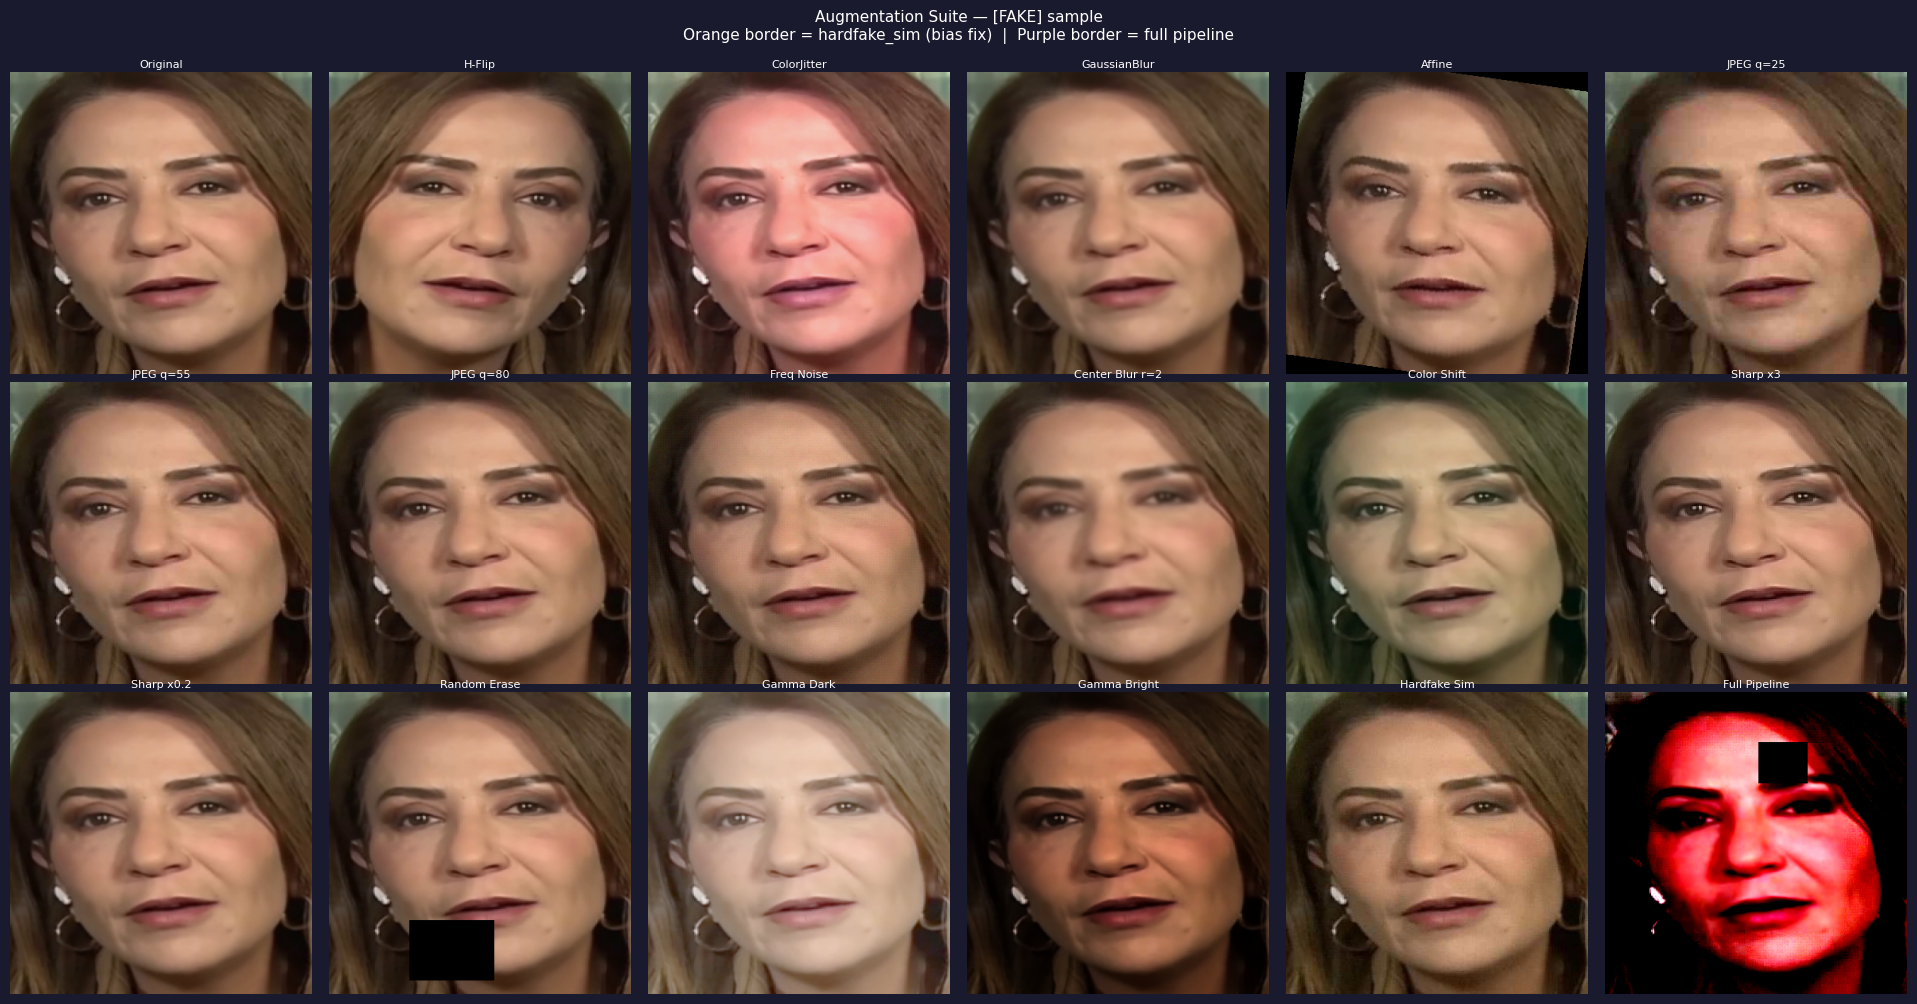

Saved: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\aug_viz_fake.png


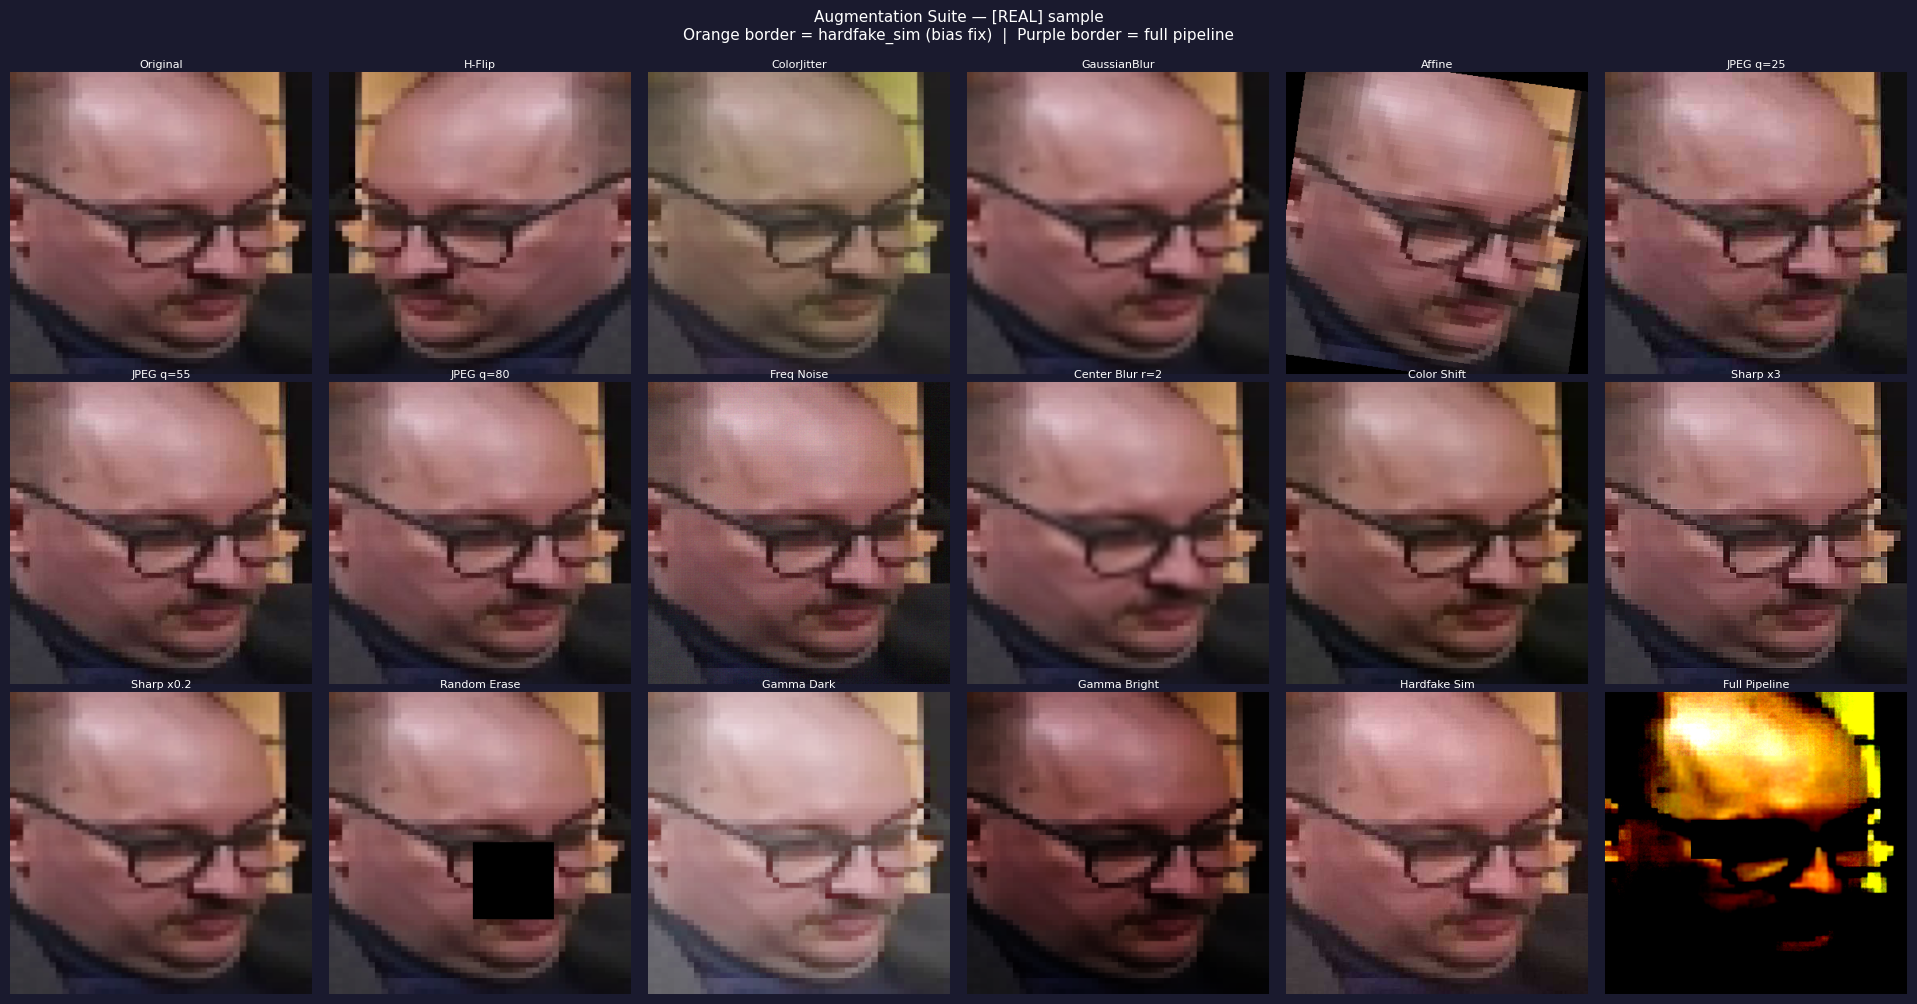

Saved: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\aug_viz_real.png


In [5]:
# Augmentation Visualization
def visualize_augmentations(h5_path, save_dir):
    with h5py.File(h5_path, 'r') as hf:
        labels = hf['labels'][:N_VALID].astype(int)
        fake_idx = int(np.where(labels == 1)[0][0])
        real_idx = int(np.where(labels == 0)[0][0])
        raw_fake = hf['faces'][fake_idx].astype(np.float32)
        raw_real = hf['faces'][real_idx].astype(np.float32)

    frame_fake = torch.from_numpy(raw_fake[7]).permute(2, 0, 1)
    frame_real = torch.from_numpy(raw_real[7]).permute(2, 0, 1)
    img_fake   = denorm(frame_fake)
    img_real   = denorm(frame_real)

    aug_pipeline = [
        ('Original',          lambda x: x),
        ('H-Flip',            lambda x: transforms.functional.hflip(x)),
        ('ColorJitter',       lambda x: transforms.ColorJitter(0.30, 0.30, 0.20, 0.08)(x)),
        ('GaussianBlur',      lambda x: transforms.GaussianBlur(5, sigma=1.5)(x)),
        ('Affine',            lambda x: transforms.functional.affine(x, angle=8, translate=[0,0], scale=1.0, shear=0)),
        ('JPEG q=25',         lambda x: jpeg_compress(x, (25, 25))),
        ('JPEG q=55',         lambda x: jpeg_compress(x, (55, 55))),
        ('JPEG q=80',         lambda x: jpeg_compress(x, (80, 80))),
        ('Freq Noise',        lambda x: freq_noise(x, (0.02, 0.03))),
        ('Center Blur r=2',   lambda x: center_blur(x, (2.0, 2.0))),
        ('Color Shift',       lambda x: color_shift(x, 0.06)),
        ('Sharp x3',          lambda x: sharpness_jitter(x, (3.0, 3.0))),
        ('Sharp x0.2',        lambda x: sharpness_jitter(x, (0.2, 0.2))),
        ('Random Erase',      lambda x: random_erase(x, p=1.0, scale=(0.05, 0.08))),
        ('Gamma Dark',        lambda x: gamma_jitter(x, (0.6, 0.6))),
        ('Gamma Bright',      lambda x: gamma_jitter(x, (1.6, 1.6))),
        ('Hardfake Sim',      lambda x: hardfake_sim(x)),
        ('Full Pipeline',     lambda x: renorm(gamma_jitter(
                                  random_erase(
                                  center_blur(
                                  sharpness_jitter(
                                  color_shift(
                                  freq_noise(
                                  jpeg_compress(
                                  color_shift(
                                  SPATIAL_AUG(x)))))))))).clamp(-3.5, 3.5)),
    ]

    n_cols = 6
    n_rows = (len(aug_pipeline) + n_cols - 1) // n_cols
    fig_h  = n_rows * 3.0

    for img_src, class_tag, face_color in [
        (img_fake, 'FAKE', '#c0392b'),
        (img_real, 'REAL', '#1a6b2a'),
    ]:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.2, fig_h + 0.8))
        axes = axes.flatten()
        fig.patch.set_facecolor('#1a1a2e')

        for i, (name, fn) in enumerate(aug_pipeline):
            try:
                out = fn(img_src.clone())
                if out.shape == img_src.shape and out.abs().max() > 3.0:
                    out = denorm(out.clamp(-3.5, 3.5))
                out = out.clamp(0, 1).permute(1, 2, 0).numpy()
            except Exception:
                out = img_src.clamp(0, 1).permute(1, 2, 0).numpy()

            axes[i].imshow(out)
            axes[i].set_title(name, fontsize=8, color='white', pad=3)
            axes[i].axis('off')

            if name == 'Original':
                for spine in axes[i].spines.values():
                    spine.set_edgecolor(face_color)
                    spine.set_linewidth(3)
            elif name == 'Hardfake Sim':
                for spine in axes[i].spines.values():
                    spine.set_edgecolor('#f39c12')
                    spine.set_linewidth(3)
            elif name == 'Full Pipeline':
                for spine in axes[i].spines.values():
                    spine.set_edgecolor('#8e44ad')
                    spine.set_linewidth(3)

        for j in range(len(aug_pipeline), len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(
            f'Augmentation Suite — [{class_tag}] sample\n'
            f'Orange border = hardfake_sim (bias fix)  |  Purple border = full pipeline',
            fontsize=11, color='white', y=1.01
        )
        plt.tight_layout(pad=0.4)
        out_path = os.path.join(SAVE_DIR, f'aug_viz_{class_tag.lower()}.png')
        plt.savefig(out_path, dpi=120, bbox_inches='tight', facecolor=fig.get_facecolor())
        plt.show()
        print(f'Saved: {out_path}')

    torch.cuda.empty_cache()
    gc.collect()

visualize_augmentations(H5_PATH, SAVE_DIR)

In [6]:
# Fine-tune Dataset

class FineTuneDataset(Dataset):

    def __init__(self, h5_path, indices, augment=False):
        self.h5_path = h5_path
        self.indices = list(indices)
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, item):
        idx = self.indices[item]
        with h5py.File(self.h5_path, 'r') as hf:
            faces = hf['faces'][idx].astype(np.float32)
            label = int(hf['labels'][idx])

        frames = []
        for i in range(N_FRAMES):
            frame = np.clip(faces[i], -3.5, 3.5)
            if not np.isfinite(frame).all():
                frame = np.zeros_like(frame)
            t = torch.from_numpy(frame).permute(2, 0, 1)

            if self.augment:
                img = denorm(t)
                img = SPATIAL_AUG(img)

                if random.random() < 0.55:
                    img = jpeg_compress(img, quality_range=(25, 90))
                if random.random() < 0.35:
                    img = freq_noise(img)
                if random.random() < 0.40:
                    img = color_shift(img)
                if random.random() < 0.30:
                    img = sharpness_jitter(img)
                if random.random() < 0.25:
                    img = center_blur(img)
                if random.random() < 0.30:
                    img = gamma_jitter(img)

                img = random_erase(img, p=0.30)

                if label == 0 and random.random() < 0.15:
                    img = hardfake_sim(img)

                t = renorm(img)

            frames.append(t)

        if self.augment and random.random() < 0.25:
            for di in random.sample(range(N_FRAMES), random.randint(1, 2)):
                frames[di] = torch.zeros(3, IMG_SIZE, IMG_SIZE)

        return torch.stack(frames, dim=0), torch.tensor(label, dtype=torch.float32)

print('FineTuneDataset defined.')


FineTuneDataset defined.


In [7]:
# Data Split and DataLoaders
all_indices = np.arange(N_VALID)
train_idx, temp_idx, y_train, y_temp = train_test_split(
    all_indices, ALL_LABELS, test_size=0.20, stratify=ALL_LABELS, random_state=42
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f'Train : {len(train_idx)}  ({(y_train==1).sum()} fake | {(y_train==0).sum()} real)')
print(f'Val   : {len(val_idx)}   ({(y_val==1).sum()} fake | {(y_val==0).sum()} real)')
print(f'Test  : {len(test_idx)}  ({(y_test==1).sum()} fake | {(y_test==0).sum()} real)')

class_counts   = np.bincount(y_train)
sample_weights = (1.0 / class_counts)[y_train]
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(train_idx),
    replacement=True
)

train_ds = FineTuneDataset(H5_PATH, train_idx, augment=True)
val_ds   = FineTuneDataset(H5_PATH, val_idx,   augment=False)
test_ds  = FineTuneDataset(H5_PATH, test_idx,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f'Train batches : {len(train_loader)}')
sx, sy = next(iter(train_loader))
print(f'Batch shape   : {sx.shape}')
print(f'Value range   : {sx.min():.3f} to {sx.max():.3f}')
assert sx.abs().max() > 0.5, 'FATAL: data range wrong.'
print('Sanity check passed.')
del sx, sy
torch.cuda.empty_cache()
gc.collect()


Train : 7112  (3613 fake | 3499 real)
Val   : 889   (452 fake | 437 real)
Test  : 890  (452 fake | 438 real)
Train batches : 1778
Batch shape   : torch.Size([4, 15, 3, 380, 380])
Value range   : -2.118 to 2.640
Sanity check passed.


47720

In [8]:
# Model Architecture

class TemporalAttention(nn.Module):

    def __init__(self, hidden_dim, attention_dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim * 2, attention_dim),
            nn.Tanh(),
            nn.Linear(attention_dim, 1, bias=False)
        )

    def forward(self, lstm_out):
        scores  = self.attn(lstm_out).squeeze(-1)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        context = (lstm_out * weights).sum(dim=1)
        return context, weights.squeeze(-1)


class DeepfakeDetector(nn.Module):

    def __init__(self):
        super().__init__()
        backbone  = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        self.cnn  = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)

        for p in self.cnn.parameters():
            p.requires_grad = False

        self.cnn_drop   = nn.Dropout(0.2)
        self.frame_proj = nn.Sequential(
            nn.Linear(1792, 512),
            nn.LayerNorm(512),
            nn.SiLU(),
            nn.Dropout(0.3)
        )
        self.bilstm = nn.LSTM(
            input_size=512,
            hidden_size=LSTM_HIDDEN,
            num_layers=LSTM_LAYERS,
            batch_first=True,
            bidirectional=True,
            dropout=DROPOUT if LSTM_LAYERS > 1 else 0.0
        )
        self.attention  = TemporalAttention(LSTM_HIDDEN, ATTENTION_DIM)
        self.classifier = nn.Sequential(
            nn.Linear(LSTM_HIDDEN * 2, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, 1)
        )
        self._init_weights()

    def _init_weights(self):
        for name, p in self.bilstm.named_parameters():
            if 'weight_ih' in name:   nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias' in name:      nn.init.zeros_(p)
        for m in [*self.frame_proj, *self.classifier]:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        B, T, C, H, W = x.shape
        x_flat = x.contiguous().view(B * T, C, H, W)
        if self.training:
            feats = grad_ckpt(self.cnn, x_flat, use_reentrant=False)
        else:
            with torch.no_grad():
                feats = self.cnn(x_flat)
        feats    = self.pool(feats).view(B * T, -1)
        feats    = self.cnn_drop(feats)
        feats    = feats.view(B, T, -1)
        feats    = self.frame_proj(feats)
        lstm_out, _ = self.bilstm(feats)
        context, attn_weights = self.attention(lstm_out)
        logit = self.classifier(context).squeeze(-1)
        return logit, attn_weights


model   = DeepfakeDetector().to(DEVICE)
total_p = sum(p.numel() for p in model.parameters())
print(f'Total parameters : {total_p:,}')
torch.cuda.empty_cache()
gc.collect()


Total parameters : 21,753,417


9

In [9]:
# Load Base Checkpoint and Unfreeze Last 3 CNN Blocks

print(f'Loading: {BASE_CKPT}')
ckpt         = torch.load(BASE_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
BASE_VAL_AUC = float(ckpt['val_auc'])
BASE_EPOCH   = int(ckpt['epoch'])
print(f'Loaded epoch {BASE_EPOCH}  ->  base val AUC: {BASE_VAL_AUC:.4f}')

for p in model.cnn.parameters():
    p.requires_grad = False
for p in model.cnn[-3:].parameters():
    p.requires_grad = True

bb_train = sum(p.numel() for p in model.cnn.parameters() if p.requires_grad)
bb_total = sum(p.numel() for p in model.cnn.parameters())
hd_train = sum(
    p.numel() for m in [model.frame_proj, model.bilstm,
                         model.attention, model.classifier, model.cnn_drop]
    for p in m.parameters()
)
print(f'Backbone trainable : {bb_train:,} / {bb_total:,}  ({bb_train/bb_total:.1%})')
print(f'Head trainable     : {hd_train:,}')
print(f'Target to beat     : val AUC {BASE_VAL_AUC:.4f}')
torch.cuda.empty_cache()
gc.collect()
if torch.cuda.is_available():
    print(f'GPU mem after load : {torch.cuda.memory_allocated()/1e9:.2f} GB')


Loading: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\best_model.pth
Loaded epoch 15  ->  base val AUC: 0.9166
Backbone trainable : 13,912,632 / 17,548,616  (79.3%)
Head trainable     : 4,204,801
Target to beat     : val AUC 0.9166
GPU mem after load : 0.18 GB


In [10]:
# Loss Function, Optimizer, Scheduler

class FocalLabelSmoothBCE(nn.Module):

    def __init__(self, smoothing=0.10, gamma=1.5, pos_weight=None):
        super().__init__()
        self.smoothing  = smoothing
        self.gamma      = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        smooth  = targets * (1.0 - self.smoothing) + self.smoothing * 0.5
        bce = F.binary_cross_entropy_with_logits(
            logits, smooth, pos_weight=self.pos_weight, reduction='none')
        p_t = torch.sigmoid(logits.detach()) * targets + (1 - torch.sigmoid(logits.detach())) * (1 - targets)
        return ((1.0 - p_t) ** self.gamma * bce).mean()


n_fake_tr  = int((y_train == 1).sum())
n_real_tr  = int((y_train == 0).sum())
pos_weight = torch.tensor([n_real_tr / n_fake_tr], dtype=torch.float32).to(DEVICE)
criterion  = FocalLabelSmoothBCE(smoothing=LABEL_SMOOTH, gamma=1.5, pos_weight=pos_weight)
print(f'pos_weight: {pos_weight.item():.4f}')

backbone_params = [p for p in model.cnn.parameters() if p.requires_grad]
head_params = (
    list(model.frame_proj.parameters()) +
    list(model.bilstm.parameters())     +
    list(model.attention.parameters())  +
    list(model.classifier.parameters()) +
    list(model.cnn_drop.parameters())
)

optimizer = torch.optim.AdamW([
    {'params': backbone_params, 'lr': LR * 0.1},
    {'params': head_params,     'lr': LR},
], weight_decay=WEIGHT_DECAY)


def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    t = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + np.cos(np.pi * t))


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = torch.cuda.amp.GradScaler(enabled=MIXED_PREC)

print(f'Backbone LR : {LR * 0.1:.2e}')
print(f'Head LR     : {LR:.2e}')
print(f'Focal gamma : 1.5')


pos_weight: 0.9684
Backbone LR : 5.00e-07
Head LR     : 5.00e-06
Focal gamma : 1.5


In [11]:
# Training and Evaluation Functions

def mixup_batch(x, y, alpha=0.3):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[idx], lam * y + (1 - lam) * y[idx]


def train_one_epoch(model, loader, optimizer, criterion, scaler, epoch):
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_probs  = []
    all_lbls   = []

    optimizer.zero_grad(set_to_none=True)
    pbar = tqdm(loader, desc=f'FT Ep{epoch:02d}', leave=False, dynamic_ncols=True)

    for step, (x, y) in enumerate(pbar):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if torch.isnan(x).any():
            continue

        y_mix = y
        if random.random() < MIXUP_PROB:
            x, y_mix = mixup_batch(x, y, alpha=0.3)

        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logits, _ = model(x)
            if torch.isnan(logits).any():
                continue
            loss = criterion(logits, y_mix) / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            torch.cuda.empty_cache()

        with torch.no_grad():
            probs = torch.sigmoid(logits.detach())
            preds = (probs > 0.5).float()
            correct    += (preds == y).sum().item()
            total      += y.size(0)
            total_loss += loss.item() * ACCUM_STEPS * y.size(0)
            all_probs.extend(probs.cpu().numpy().tolist())
            all_lbls.extend(y.cpu().numpy().tolist())

        pbar.set_postfix({'loss': f'{total_loss/max(total,1):.4f}',
                          'acc':  f'{100*correct/max(total,1):.1f}%'})

    try:
        auc = roc_auc_score(all_lbls, all_probs)
    except Exception:
        auc = 0.5
    return total_loss / max(total, 1), correct / max(total, 1), auc


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct    = 0
    total      = 0
    all_probs  = []
    all_lbls   = []

    for x, y in tqdm(loader, desc='Val', leave=False, dynamic_ncols=True):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        if torch.isnan(x).any():
            continue

        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logits, _ = model(x)
            loss      = criterion(logits, y)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct    += (preds == y).sum().item()
        total      += y.size(0)
        total_loss += loss.item() * y.size(0)
        all_probs.extend(probs.cpu().numpy().tolist())
        all_lbls.extend(y.cpu().numpy().tolist())

    try:
        auc = roc_auc_score(all_lbls, all_probs)
    except Exception:
        auc = 0.5
    return total_loss / max(total, 1), correct / max(total, 1), auc

print('Train and eval functions defined.')


Train and eval functions defined.


In [12]:
# Fine-tune Training Loop

ft_history = {k: [] for k in
    ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc','lr']}

best_val_auc   = 0.0
patience_count = 0
best_epoch     = 0

print('Starting fine-tune v3')
print(f'Base val AUC to beat: {BASE_VAL_AUC:.4f}')
print('=' * 72)
t_start = time.time()

for epoch in range(1, EPOCHS + 1):
    ep_t = time.time()

    tr_loss, tr_acc, tr_auc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, epoch
    )
    torch.cuda.empty_cache()
    gc.collect()

    vl_loss, vl_acc, vl_auc = evaluate(model, val_loader, criterion)
    torch.cuda.empty_cache()
    gc.collect()

    scheduler.step()
    current_lr = optimizer.param_groups[-1]['lr']

    for k, v in zip(
        ['train_loss','val_loss','train_acc','val_acc','train_auc','val_auc','lr'],
        [tr_loss, vl_loss, tr_acc, vl_acc, tr_auc, vl_auc, current_lr]
    ):
        ft_history[k].append(v)

    ep_min   = (time.time() - ep_t) / 60
    new_best = vl_auc > best_val_auc
    marker   = '  <-- NEW BEST' if new_best else ''

    print(
        f'FT {epoch:03d}/{EPOCHS}  LR: {current_lr:.2e}  {ep_min:.1f}min'
        f'  |  Train: Loss={tr_loss:.4f} Acc={tr_acc*100:.2f}% AUC={tr_auc:.4f}'
        f'  |  Val: Loss={vl_loss:.4f} Acc={vl_acc*100:.2f}% AUC={vl_auc:.4f}{marker}'
    )

    if new_best:
        best_val_auc   = vl_auc
        best_epoch     = epoch
        patience_count = 0
        torch.save({
            'epoch':        epoch,
            'model_state':  model.state_dict(),
            'val_auc':      vl_auc,
            'val_acc':      vl_acc,
            'train_auc':    tr_auc,
            'train_acc':    tr_acc,
            'base_val_auc': BASE_VAL_AUC,
            'base_epoch':   BASE_EPOCH,
        }, FT_CKPT)
        print(f'          Saved -> {FT_CKPT}')
    else:
        patience_count += 1

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

    torch.cuda.empty_cache()
    gc.collect()

total_min = (time.time() - t_start) / 60
print(f'\nDone in {total_min:.1f} min  |  Best epoch: {best_epoch}'
      f'  |  Best val AUC: {best_val_auc:.4f}'
      f'  |  Improvement: {best_val_auc - BASE_VAL_AUC:+.4f}')


Starting fine-tune v3
Base val AUC to beat: 0.9166


FT 001/20  LR: 5.00e-06  168.0min  |  Train: Loss=0.1736 Acc=76.56% AUC=0.8440  |  Val: Loss=0.1773 Acc=83.35% AUC=0.9026  <-- NEW BEST
          Saved -> C:\Users\abida\CNN+LSTM Results\checkpoints_v3\finetuned_model_v3.pth


FT 002/20  LR: 5.00e-06  166.7min  |  Train: Loss=0.1543 Acc=77.70% AUC=0.8511  |  Val: Loss=0.1511 Acc=84.25% AUC=0.9045  <-- NEW BEST
          Saved -> C:\Users\abida\CNN+LSTM Results\checkpoints_v3\finetuned_model_v3.pth


FT 003/20  LR: 4.96e-06  167.6min  |  Train: Loss=0.1510 Acc=77.53% AUC=0.8525  |  Val: Loss=0.1502 Acc=80.99% AUC=0.9010


FT 004/20  LR: 4.85e-06  167.6min  |  Train: Loss=0.1413 Acc=79.05% AUC=0.8653  |  Val: Loss=0.1454 Acc=82.11% AUC=0.9007


...

FT 009/20  LR: 3.36e-06  167.8min  |  Train: Loss=0.1390 Acc=79.92% AUC=0.8781  |  Val: Loss=0.1441 Acc=83.01% AUC=0.9079


FT 010/20  LR: 2.93e-06  167.9min  |  Train: Loss=0.1348 Acc=79.85% AUC=0.8765  |  Val: Loss=0.1430 Acc=83.80% AUC=0.9099


FT 011/20  LR: 2.50e-06  172.5min  |  Train: Loss=0.1335 Acc=80.37% AUC=0.8851  |  Val: Loss=0.1434 Acc=84.25% AUC=0.9108


FT 012/20  LR: 2.07e-06  168.0min  |  Train: Loss=0.1319 Acc=80.84% AUC=0.8901  |  Val: Loss=0.1486 Acc=83.35% AUC=0.9092


FT 013/20  LR: 1.64e-06  167.4min  |  Train: Loss=0.1373 Acc=79.89% AUC=0.8787  |  Val: Loss=0.1446 Acc=83.13% AUC=0.9013

Early stopping at epoch 13.

Done in 2188.7 min  |  Best epoch: 8  |  Best val AUC: 0.9123  |  Improvement: -0.0043


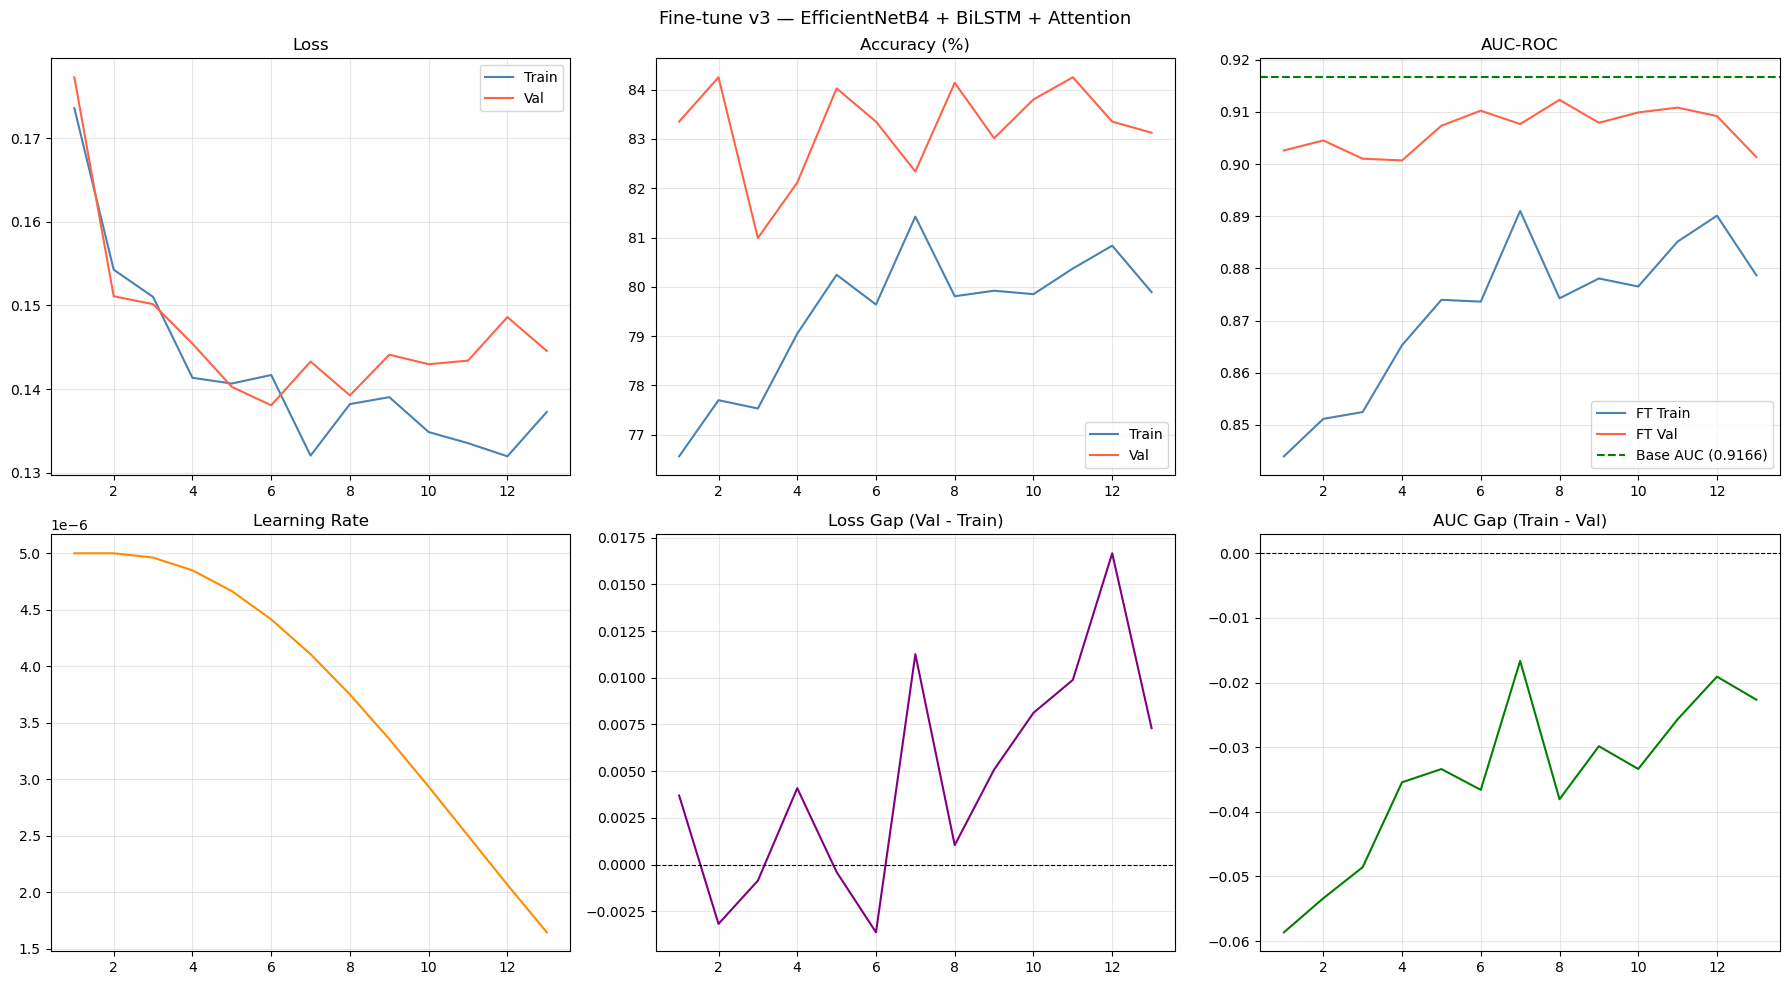

Saved: C:\Users\abida\CNN+LSTM Results\checkpoints_v3\ftv3_curves.png


In [13]:
# Training Curves

def plot_ft_history(history, save_dir, base_val_auc):
    ep  = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Fine-tune v3 — EfficientNetB4 + BiLSTM + Attention', fontsize=13)

    axes[0,0].plot(ep, history['train_loss'], label='Train', color='steelblue')
    axes[0,0].plot(ep, history['val_loss'],   label='Val',   color='tomato')
    axes[0,0].set_title('Loss')
    axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(ep, [v*100 for v in history['train_acc']], label='Train', color='steelblue')
    axes[0,1].plot(ep, [v*100 for v in history['val_acc']],   label='Val',   color='tomato')
    axes[0,1].set_title('Accuracy (%)')
    axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

    axes[0,2].plot(ep, history['train_auc'], label='FT Train', color='steelblue')
    axes[0,2].plot(ep, history['val_auc'],   label='FT Val',   color='tomato')
    axes[0,2].axhline(base_val_auc, color='green', linestyle='--', linewidth=1.5,
                      label=f'Base AUC ({base_val_auc:.4f})')
    axes[0,2].set_title('AUC-ROC')
    axes[0,2].legend(); axes[0,2].grid(True, alpha=0.3)

    axes[1,0].plot(ep, history['lr'], color='darkorange')
    axes[1,0].set_title('Learning Rate'); axes[1,0].grid(True, alpha=0.3)

    gap_loss = [v - t for t, v in zip(history['train_loss'], history['val_loss'])]
    gap_auc  = [t - v for t, v in zip(history['train_auc'],  history['val_auc'])]
    axes[1,1].plot(ep, gap_loss, color='purple')
    axes[1,1].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1,1].set_title('Loss Gap (Val - Train)'); axes[1,1].grid(True, alpha=0.3)

    axes[1,2].plot(ep, gap_auc, color='green')
    axes[1,2].axhline(0, color='black', linewidth=0.8, linestyle='--')
    axes[1,2].set_title('AUC Gap (Train - Val)'); axes[1,2].grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(save_dir, 'ftv3_curves.png')
    plt.savefig(out, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

plot_ft_history(ft_history, SAVE_DIR, BASE_VAL_AUC)

with open(os.path.join(SAVE_DIR, 'ftv3_history.json'), 'w') as f:
    json.dump({k: [float(v) for v in vs] for k, vs in ft_history.items()}, f, indent=2)


FT epoch     : 8
FT val AUC   : 0.9123
Base val AUC : 0.9166
Improvement  : -0.0043


Threshold search (val): 100%|████████████████████████████████████████████████████████| 223/223 [03:34<00:00,  1.04it/s]



Optimal threshold : 0.48  (val F1 = 0.8419)


Testing: 100%|███████████████████████████████████████████████████████████████████████| 223/223 [03:57<00:00,  1.06s/it]



FINE-TUNED V3 — FINAL TEST RESULTS
Accuracy  : 79.21%  (threshold = 0.48)
ROC-AUC   : 0.8799

              precision    recall  f1-score   support

        Real     0.7817    0.8014    0.7914       438
        Fake     0.8027    0.7832    0.7928       452

    accuracy                         0.7921       890
   macro avg     0.7922    0.7923    0.7921       890
weighted avg     0.7924    0.7921    0.7921       890



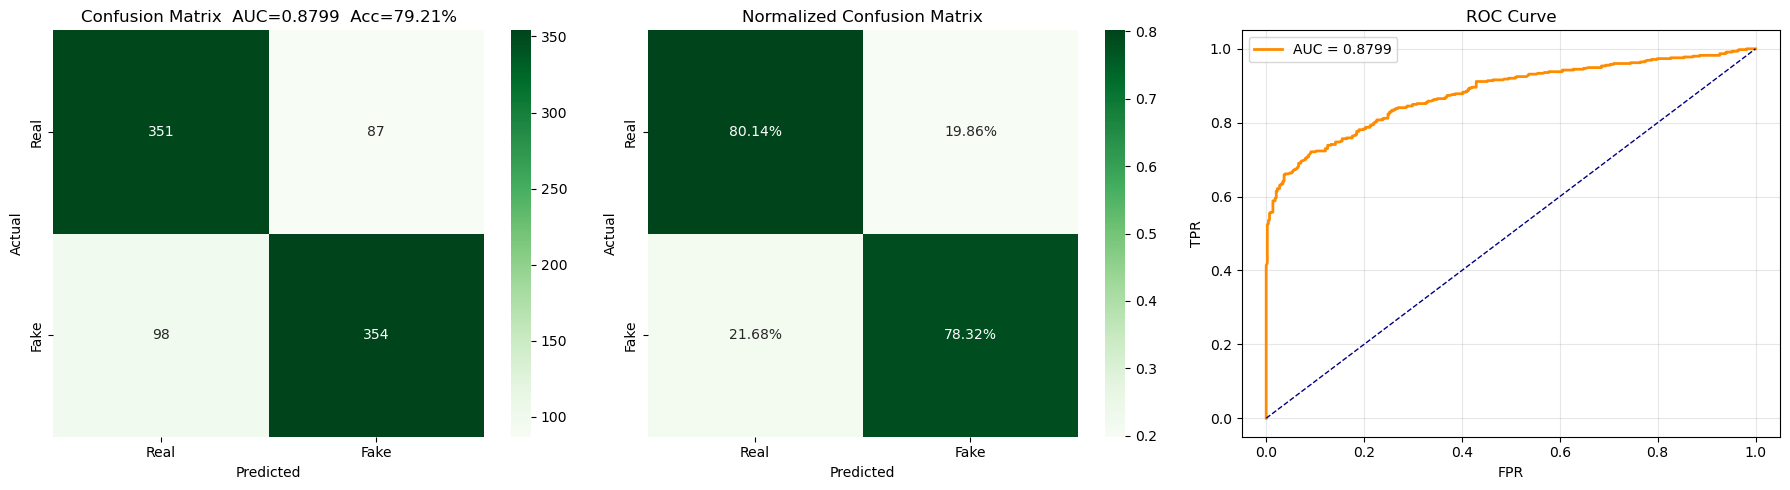

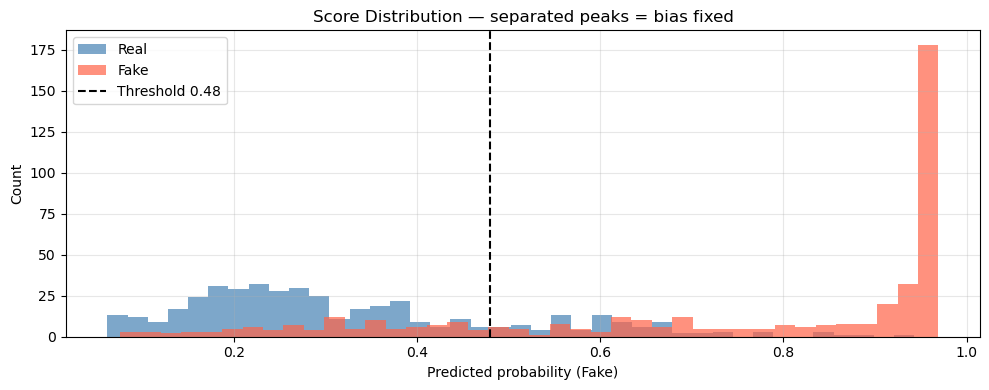

In [14]:
# Test Evaluation with Optimal Threshold

if not os.path.exists(FT_CKPT):
    print('finetuned_model_v3.pth not found. Fine-tune did not save a better model.')
else:
    ft_ckpt = torch.load(FT_CKPT, map_location=DEVICE)
    model.load_state_dict(ft_ckpt['model_state'])
    print(f'FT epoch     : {ft_ckpt["epoch"]}')
    print(f'FT val AUC   : {ft_ckpt["val_auc"]:.4f}')
    print(f'Base val AUC : {ft_ckpt["base_val_auc"]:.4f}')
    print(f'Improvement  : {ft_ckpt["val_auc"] - ft_ckpt["base_val_auc"]:+.4f}')

    model.eval()

    # Find optimal threshold on validation set
    val_probs, val_lbls = [], []
    with torch.no_grad():
        for x, y in tqdm(val_loader, desc='Threshold search (val)'):
            x = x.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=MIXED_PREC):
                logits, _ = model(x)
            val_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
            val_lbls.extend(y.numpy().astype(int).tolist())
    val_probs = np.array(val_probs)
    val_lbls  = np.array(val_lbls)

    thresholds = np.linspace(0.30, 0.70, 41)
    f1_scores  = [f1_score(val_lbls, (val_probs >= t).astype(int)) for t in thresholds]
    BEST_THRESH = float(thresholds[np.argmax(f1_scores)])
    print(f'\nOptimal threshold : {BEST_THRESH:.2f}  (val F1 = {max(f1_scores):.4f})')

    # Test set evaluation
    all_probs, all_preds, all_labels, all_attns = [], [], [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc='Testing'):
            x = x.to(DEVICE)
            with torch.cuda.amp.autocast(enabled=MIXED_PREC):
                logits, attn_w = model(x)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.tolist())
            all_preds.extend((probs >= BEST_THRESH).astype(int).tolist())
            all_labels.extend(y.numpy().astype(int).tolist())
            all_attns.extend(attn_w.cpu().numpy().tolist())

    all_probs  = np.array(all_probs)
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    test_auc = roc_auc_score(all_labels, all_probs)
    test_acc = (all_preds == all_labels).mean()

    print('\n' + '=' * 55)
    print('FINE-TUNED V3 — FINAL TEST RESULTS')
    print('=' * 55)
    print(f'Accuracy  : {test_acc*100:.2f}%  (threshold = {BEST_THRESH:.2f})')
    print(f'ROC-AUC   : {test_auc:.4f}')
    print()
    print(classification_report(all_labels, all_preds, target_names=['Real','Fake'], digits=4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
    axes[0].set_title(f'Confusion Matrix  AUC={test_auc:.4f}  Acc={test_acc*100:.2f}%')

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
                xticklabels=['Real','Fake'], yticklabels=['Real','Fake'])
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
    axes[1].set_title('Normalized Confusion Matrix')

    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    axes[2].plot(fpr, tpr, color='darkorange', linewidth=2, label=f'AUC = {test_auc:.4f}')
    axes[2].plot([0,1],[0,1], color='navy', linestyle='--', linewidth=1)
    axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
    axes[2].set_title('ROC Curve'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'ftv3_test_results.png'), dpi=130, bbox_inches='tight')
    plt.show()

    # Score distribution — shows if bias is fixed
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(all_probs[all_labels==0], bins=40, alpha=0.7, label='Real', color='steelblue')
    ax.hist(all_probs[all_labels==1], bins=40, alpha=0.7, label='Fake', color='tomato')
    ax.axvline(BEST_THRESH, color='black', linestyle='--', label=f'Threshold {BEST_THRESH:.2f}')
    ax.set_xlabel('Predicted probability (Fake)'); ax.set_ylabel('Count')
    ax.set_title('Score Distribution — separated peaks = bias fixed')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'ftv3_score_dist.png'), dpi=130)
    plt.show()

    with open(os.path.join(SAVE_DIR, 'ftv3_test_results.json'), 'w') as f:
        json.dump({'test_accuracy': float(test_acc), 'test_auc': float(test_auc),
                   'threshold': float(BEST_THRESH), 'ft_epoch': int(ft_ckpt['epoch']),
                   'base_val_auc': float(ft_ckpt['base_val_auc'])}, f, indent=2)


Model : finetuned_model_v3.pth  val AUC: 0.9123
Threshold : 0.48


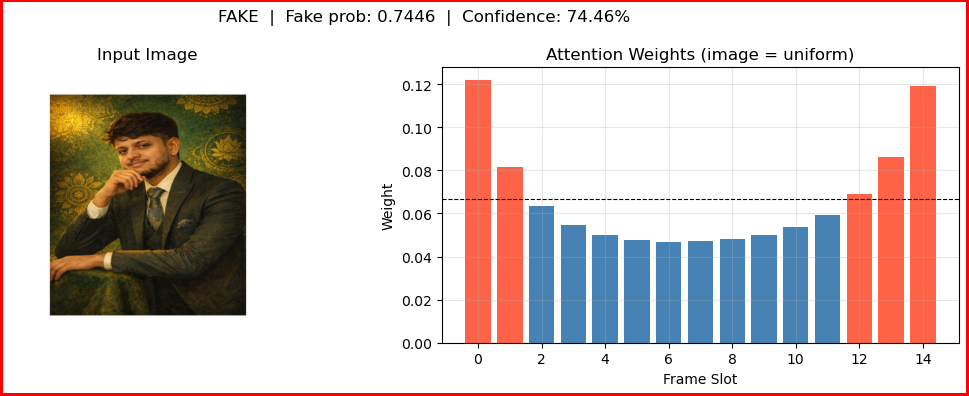

Prediction : FAKE  |  Fake prob: 0.7446  |  Confidence: 74.46%


In [30]:
# Image Inference

from PIL import Image as PILImage

_ckpt_path = FT_CKPT if os.path.exists(FT_CKPT) else BASE_CKPT
_ckpt_data = torch.load(_ckpt_path, map_location=DEVICE)
model.load_state_dict(_ckpt_data['model_state'])
model.eval()
_THRESH = BEST_THRESH if 'BEST_THRESH' in dir() else 0.5
print(f'Model : {os.path.basename(_ckpt_path)}  val AUC: {_ckpt_data["val_auc"]:.4f}')
print(f'Threshold : {_THRESH:.2f}')


def predict_image(img_path):
    if not os.path.exists(img_path):
        print(f'Not found: {img_path}')
        return None

    img = PILImage.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
    arr = (np.array(img).astype(np.float32) / 255.0 - MEAN_NP) / STD_NP
    t   = torch.from_numpy(arr).permute(2, 0, 1)
    seq = t.unsqueeze(0).repeat(N_FRAMES, 1, 1, 1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logit, attn = model(seq)
        prob = float(torch.sigmoid(logit).item())

    label = 'FAKE' if prob >= _THRESH else 'REAL'
    conf  = prob if prob >= _THRESH else 1.0 - prob

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(np.array(img))
    axes[0].axis('off')
    axes[0].set_title('Input Image')

    attn_np = attn.cpu().numpy().flatten()
    color   = ['tomato' if a >= attn_np.mean() else 'steelblue' for a in attn_np]
    axes[1].bar(range(N_FRAMES), attn_np, color=color)
    axes[1].axhline(attn_np.mean(), color='black', linestyle='--', linewidth=0.8)
    axes[1].set_title('Attention Weights (image = uniform)')
    axes[1].set_xlabel('Frame Slot'); axes[1].set_ylabel('Weight')
    axes[1].grid(True, alpha=0.3)

    border_color = 'red' if label == 'FAKE' else 'green'
    fig.patch.set_edgecolor(border_color)
    fig.patch.set_linewidth(4)
    plt.suptitle(f'{label}  |  Fake prob: {prob:.4f}  |  Confidence: {conf:.2%}', fontsize=12)
    plt.tight_layout()
    plt.show()

    print(f'Prediction : {label}  |  Fake prob: {prob:.4f}  |  Confidence: {conf:.2%}')
    return prob


SAMPLE_IMAGE = r"D:\IMAGEDEEPFAKE\images\WhatsApp Image 2026-02-16 at 4.29.58 AM.jpeg"
if os.path.exists(SAMPLE_IMAGE):
    predict_image(SAMPLE_IMAGE)
else:
    print('Set SAMPLE_IMAGE to a real face image path to test.')


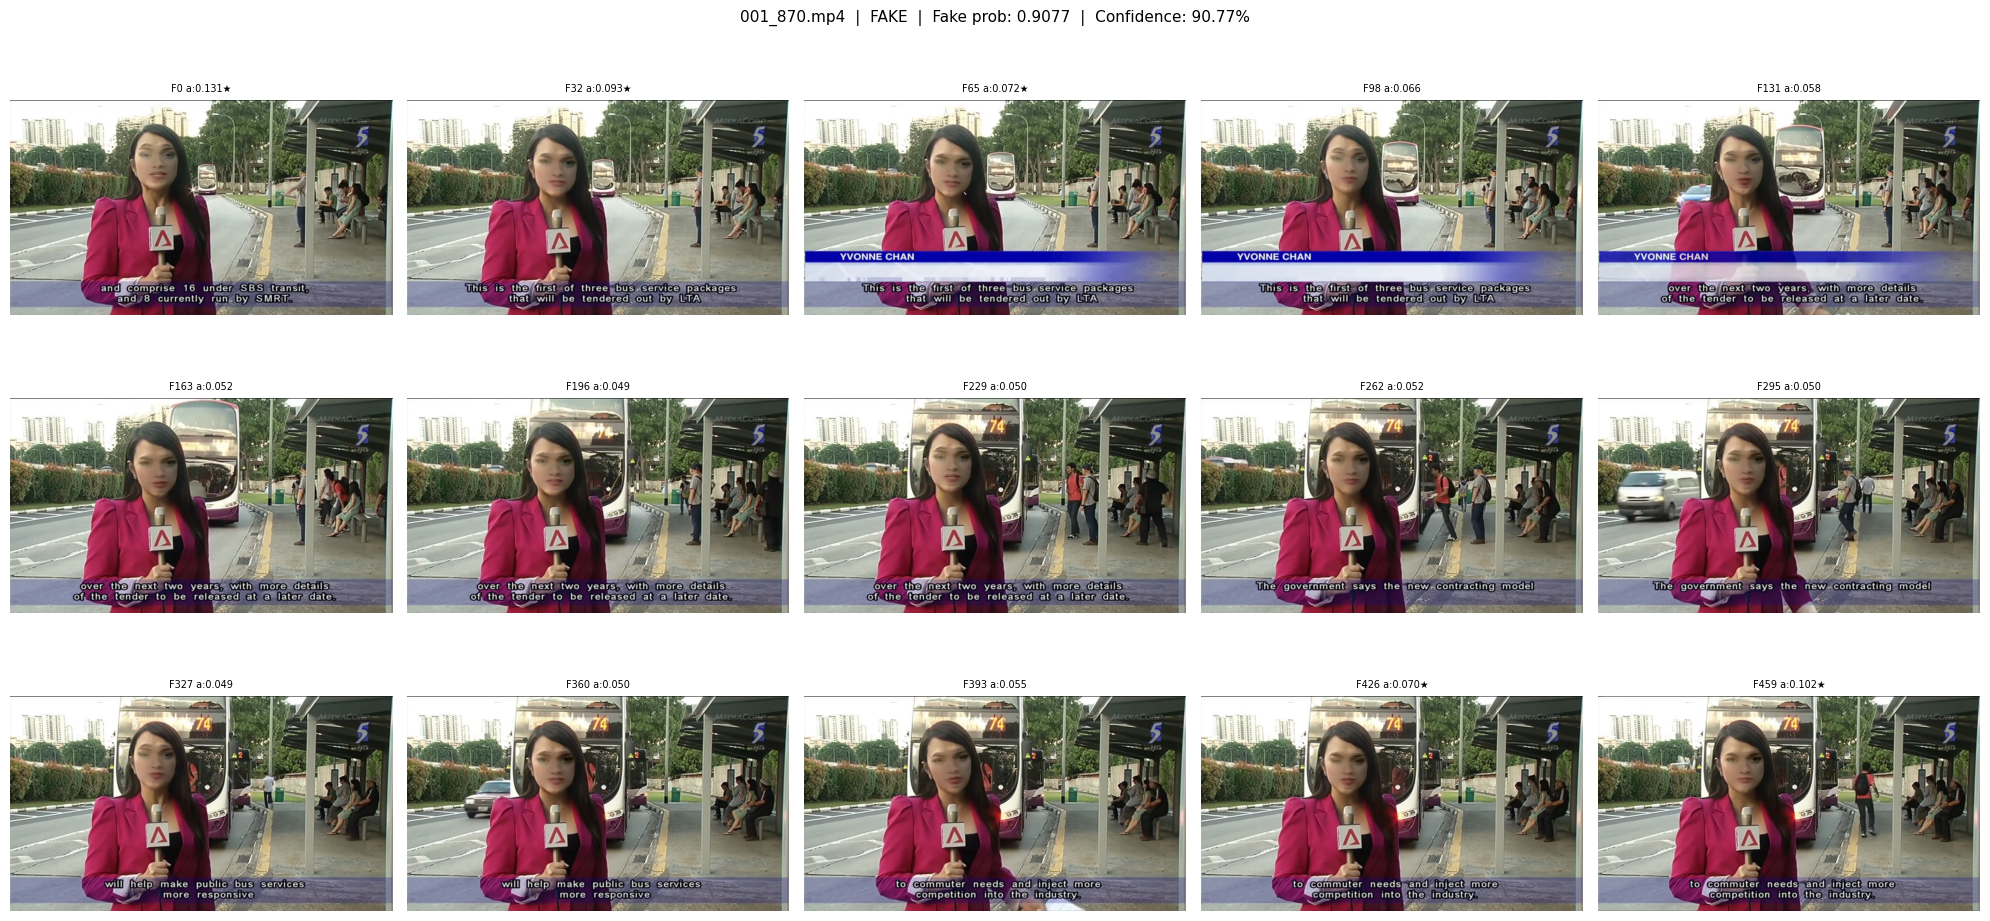

Prediction : FAKE  |  Fake prob: 0.9077  |  Confidence: 90.77%


In [28]:
# Video Inference

def predict_video(video_path):
    if not os.path.exists(video_path):
        print(f'Not found: {video_path}')
        return None

    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release()
        print('No frames found.')
        return None

    indices = np.linspace(0, total - 1, N_FRAMES, dtype=int)
    frames  = []
    for fi in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
        ret, frame = cap.read()
        if not ret:
            frames.append(frames[-1] if frames else torch.zeros(3, IMG_SIZE, IMG_SIZE))
            continue
        img = PILImage.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)).resize(
            (IMG_SIZE, IMG_SIZE), PILImage.LANCZOS
        )
        arr = (np.array(img).astype(np.float32) / 255.0 - MEAN_NP) / STD_NP
        frames.append(torch.from_numpy(arr).permute(2, 0, 1))
    cap.release()

    while len(frames) < N_FRAMES:
        frames.append(torch.zeros(3, IMG_SIZE, IMG_SIZE))

    seq = torch.stack(frames[:N_FRAMES], dim=0).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.cuda.amp.autocast(enabled=MIXED_PREC):
            logit, attn = model(seq)
        prob = float(torch.sigmoid(logit).item())

    label   = 'FAKE' if prob >= _THRESH else 'REAL'
    conf    = prob if prob >= _THRESH else 1.0 - prob
    attn_np = attn.cpu().numpy().flatten()

    cap   = cv2.VideoCapture(video_path)
    fig, axes = plt.subplots(3, 5, figsize=(20, 10))
    axes  = axes.flatten()
    for i, fi in enumerate(indices[:N_FRAMES]):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
        ret, frame = cap.read()
        if ret:
            axes[i].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        star = '★' if attn_np[i] >= attn_np.mean() else ''
        axes[i].set_title(f'F{fi} a:{attn_np[i]:.3f}{star}', fontsize=7)
        axes[i].axis('off')
    cap.release()

    plt.suptitle(
        f'{os.path.basename(video_path)}  |  {label}  |  '
        f'Fake prob: {prob:.4f}  |  Confidence: {conf:.2%}',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'last_video_inference.png'), dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Prediction : {label}  |  Fake prob: {prob:.4f}  |  Confidence: {conf:.2%}')
    return prob


SAMPLE_VIDEO = r"C:\Users\abida\VIdeo Model\001_870.mp4"
if os.path.exists(SAMPLE_VIDEO):
    predict_video(SAMPLE_VIDEO)
else:
    print('Set SAMPLE_VIDEO to a real video path to test.')


In [7]:
# Real-time Webcam Detection
from PIL import Image as PILImage
_ckpt_path = FT_CKPT if os.path.exists(FT_CKPT) else BASE_CKPT
_ckpt_data = torch.load(_ckpt_path, map_location=DEVICE)
model.load_state_dict(_ckpt_data['model_state'])
model.eval()
_THRESH = BEST_THRESH if 'BEST_THRESH' in dir() else 0.5
print(f'Model : {os.path.basename(_ckpt_path)}  val AUC: {_ckpt_data["val_auc"]:.4f}')
print(f'Threshold : {_THRESH:.2f}')

SLIDE_STEP = 5
FONT       = cv2.FONT_HERSHEY_SIMPLEX
DISPLAY_W  = 640
DISPLAY_H  = 480


def run_realtime(camera_index=0):
    cap = cv2.VideoCapture(camera_index)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH,  DISPLAY_W)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, DISPLAY_H)

    if not cap.isOpened():
        print(f'Cannot open camera {camera_index}.')
        return

    print('Webcam started.  q = quit  |  s = save buffer')

    frame_buffer    = []
    label_display   = 'Buffering...'
    prob_display    = 0.0
    new_frame_count = 0
    recording       = []

    while True:
        ret, raw = cap.read()
        if not ret:
            break

        rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
        pil = PILImage.fromarray(rgb).resize((IMG_SIZE, IMG_SIZE), PILImage.LANCZOS)
        arr = (np.array(pil).astype(np.float32) / 255.0 - MEAN_NP) / STD_NP
        frame_buffer.append(torch.from_numpy(arr).permute(2, 0, 1))
        new_frame_count += 1

        if len(frame_buffer) > N_FRAMES:
            frame_buffer.pop(0)

        if len(frame_buffer) == N_FRAMES and new_frame_count >= SLIDE_STEP:
            new_frame_count = 0
            seq = torch.stack(frame_buffer, dim=0).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                with torch.cuda.amp.autocast(enabled=MIXED_PREC):
                    logit, _ = model(seq)
                prob_display  = float(torch.sigmoid(logit).item())
            label_display = 'FAKE' if prob_display >= _THRESH else 'REAL'
            del seq
            torch.cuda.empty_cache()

        display = cv2.resize(raw, (DISPLAY_W, DISPLAY_H))
        color   = (0, 0, 255) if label_display == 'FAKE' else (0, 200, 0)
        cv2.rectangle(display, (0, 0), (DISPLAY_W-1, DISPLAY_H-1), color, 6)
        cv2.putText(display, f'{label_display}  {prob_display:.3f}',
                    (12, 42), FONT, 1.3, color, 3, cv2.LINE_AA)
        cv2.putText(display, f'Buffer {len(frame_buffer)}/{N_FRAMES}',
                    (12, DISPLAY_H-12), FONT, 0.5, (200,200,200), 1)
        cv2.imshow('Deepfake Detector v3', display)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('q'):
            break
        if key == ord('s'):
            recording.append(raw.copy())
            print(f'Saved frame {len(recording)} to buffer.')

    cap.release()
    cv2.destroyAllWindows()

    if recording:
        save_path = os.path.join(SAVE_DIR, f'webcam_{int(time.time())}.avi')
        h, w = recording[0].shape[:2]
        writer = cv2.VideoWriter(save_path, cv2.VideoWriter_fourcc(*'XVID'), 20, (w, h))
        for fr in recording:
            writer.write(fr)
        writer.release()
        print(f'Recording saved: {save_path}')


run_realtime(camera_index=0)


NameError: name 'model' is not defined

In [18]:
# ONNX Export

try:
    import onnx
    import onnxruntime as ort
    HAS_ONNX = True
except ImportError:
    HAS_ONNX = False
    print('Install: pip install onnx onnxruntime-gpu')

if HAS_ONNX:
    ONNX_PATH = os.path.join(SAVE_DIR, 'deepfake_detector_ftv3.onnx')

    class OnnxWrapper(nn.Module):
        def __init__(self, m):
            super().__init__()
            self.m = m
        def forward(self, x):
            logit, _ = self.m(x)
            return logit

    model.eval()
    wrapper = OnnxWrapper(model).to(DEVICE)
    wrapper.eval()
    dummy = torch.randn(1, N_FRAMES, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    with torch.no_grad():
        torch.onnx.export(
            wrapper, dummy, ONNX_PATH,
            input_names=['video_frames'],
            output_names=['logit'],
            dynamic_axes={'video_frames': {0: 'batch'}, 'logit': {0: 'batch'}},
            opset_version=17,
            do_constant_folding=True
        )

    onnx.checker.check_model(onnx.load(ONNX_PATH))
    print(f'ONNX saved : {ONNX_PATH}')
    print(f'Size       : {os.path.getsize(ONNX_PATH)/1e6:.1f} MB')
    print('ONNX check : PASSED')

    sess     = ort.InferenceSession(ONNX_PATH,
                  providers=['CUDAExecutionProvider','CPUExecutionProvider'])
    dummy_np = np.random.randn(1, N_FRAMES, 3, IMG_SIZE, IMG_SIZE).astype(np.float32)
    ort_out  = sess.run(None, {'video_frames': dummy_np})
    print(f'ORT output : {np.array(ort_out).shape}')
    print('ONNX Runtime : PASSED')


ONNX saved : C:\Users\abida\CNN+LSTM Results\checkpoints_v3\deepfake_detector_ftv3.onnx
Size       : 86.9 MB
ONNX check : PASSED
ORT output : (1, 1)
ONNX Runtime : PASSED
